# Chapter 6 — Density of states & PDOS of GaAs

Companion notebook to Chapter 6. We plot the total density of states
(`dos.x` output) together with the orbital-projected DOS (`projwfc.x`
output), aligned to the valence-band maximum. This reveals *what each
band is made of*. Requirements: `numpy`, `matplotlib`.

In [1]:
import numpy as np, re, glob
from pathlib import Path

d = Path('../code/06-dos')

# --- total DOS + Fermi level from dos.x ---
head = (d/'gaas.dos').read_text().splitlines()[0]
EF = float(re.search(r'EFermi\s*=\s*([-0-9.]+)', head).group(1))
E, dos, idos = np.loadtxt(d/'gaas.dos', unpack=True)
E = E - EF
print(f'EFermi (VBM) = {EF:.3f} eV  -> shifted to 0')

# --- projected DOS: group by element and orbital from the filename ---
# (projwfc.x uses its own energy grid, distinct from dos.x — read it here)
groups, Epd = {}, None
for f in glob.glob(str(d/'gaas.pdos_atm*')):
    m = re.search(r'\(([A-Za-z]+)\)_wfc#\d+\(([spdf])\)', f)
    if not m: continue
    key = f'{m.group(1)}-{m.group(2)}'
    data = np.loadtxt(f)
    Epd = data[:, 0] - EF          # pdos energy grid (shared by all pdos files)
    ldos = data[:, 1]              # column 2 = l-summed projected DOS
    groups[key] = groups.get(key, 0) + ldos
print('PDOS channels:', sorted(groups))

EFermi (VBM) = 7.969 eV  -> shifted to 0
PDOS channels: ['As-p', 'As-s', 'Ga-d', 'Ga-p', 'Ga-s']


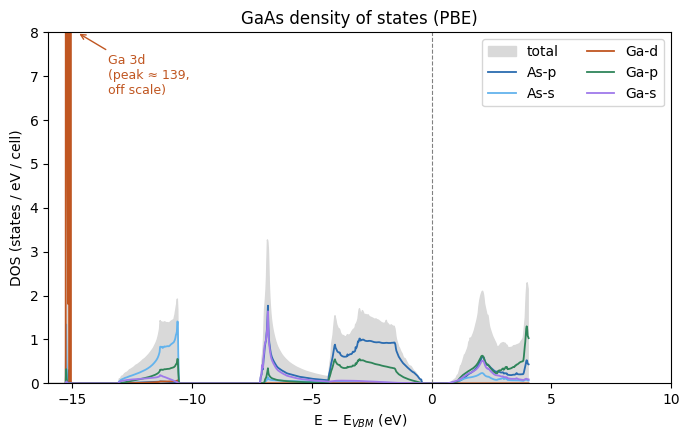

In [2]:
import matplotlib.pyplot as plt

colors = {'As-p':'#2b6cb0', 'As-s':'#63b3ed', 'Ga-d':'#c05621',
          'Ga-p':'#2f855a', 'Ga-s':'#9f7aea'}

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.fill_between(E, dos, color='0.85', label='total')
for key in ['As-p', 'As-s', 'Ga-d', 'Ga-p', 'Ga-s']:
    if key in groups:
        ax.plot(Epd, groups[key], lw=1.3, color=colors[key], label=key)
ax.axvline(0, color='gray', ls='--', lw=0.8)        # VBM
ax.set_xlim(-16, 10)
ax.set_ylim(0, 8)        # clip: the Ga 3d spike towers to ~140, off scale
gad_peak = groups['Ga-d'].max()
ax.annotate(f'Ga 3d\n(peak ≈ {gad_peak:.0f},\noff scale)',
            xy=(-14.8, 8), xytext=(-13.5, 6.6), fontsize=9,
            color='#c05621',
            arrowprops=dict(arrowstyle='->', color='#c05621'))
ax.set_xlabel('E − E$_{VBM}$ (eV)')
ax.set_ylabel('DOS (states / eV / cell)')
ax.set_title('GaAs density of states (PBE)')
ax.legend(ncol=2, loc='upper right')
fig.tight_layout()
fig.savefig(d.parent.parent/'static/img/06-dos.png', dpi=120)
plt.show()

**What you see.** The projections decompose the total DOS by orbital:

- The sharp spike near **−14.8 eV** is **Ga 3d** — narrow because those
  semicore states barely disperse (the flat bands of Chapter 5).
- The peak near **−12 to −10 eV** is mostly **As 4s** (with some Ga s).
- The upper valence band, from ~−7 eV to the VMB, is dominated by
  **As 4p** — the bonding p states.
- Above the gap the conduction band is a mix of **Ga and As s/p**.

The gap (zero DOS region) just above 0 is the same 0.51 eV gap from the
band structure. The integrated DOS up to the VBM recovers the 18 valence
electrons, and the per-orbital Löwdin charges that `projwfc.x` prints are
the same projections integrated over the occupied states.